
Сценарий 1. Главный фактор влияет
  Пейдж: F-статистика = 239.0000, p=0.000000 -> Отвергаем H0 -> Истина
  Фридман: F-статистика = 22.9500, p=0.000041 -> Отвергаем H0 -> Истина
  Двухфакторный ANOVA: F-статистика = 63.7925, p=0.000000 -> Отвергаем H0 -> Истина

Сценарий 2. Главный фактор влияет
  Пейдж: F-статистика = 236.0000, p=0.000000 -> Отвергаем H0 -> Истина
  Фридман: F-статистика = 20.7000, p=0.000122 -> Отвергаем H0 -> Истина
  Двухфакторный ANOVA: F-статистика = 23.9936, p=0.000001 -> Отвергаем H0 -> Истина
  Однофакторный ANOVA: F-статистика = 0.4574, p=0.714228 -> Принимаем H0 -> Ошибка II рода

Сценарий 3. Главный фактор влияет (тяжёлые хвосты + выброс)
  Фридман: F-статистика = 20.8500, p=0.000113 -> Отвергаем H0 -> Истина
  Двухфакторный ANOVA: F-статистика = 1.0903, p=0.374979 -> Принимаем H0 -> Ошибка II рода

Сценарий 4. Главный фактор не влияет
  Фридман: F-статистика = 0.7500, p=0.861385 -> Принимаем H0 -> Истина
  Двухфакторный ANOVA: F-статистика = 0.0387, p=0.98

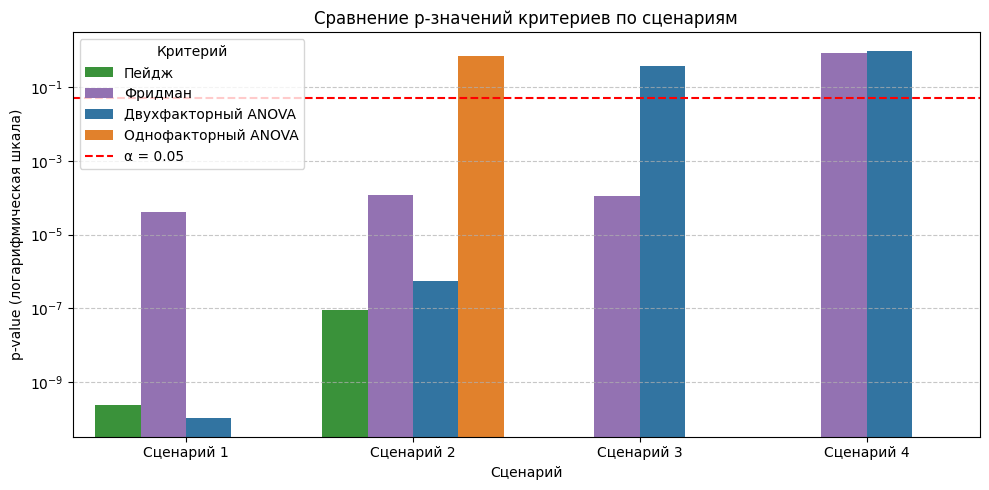

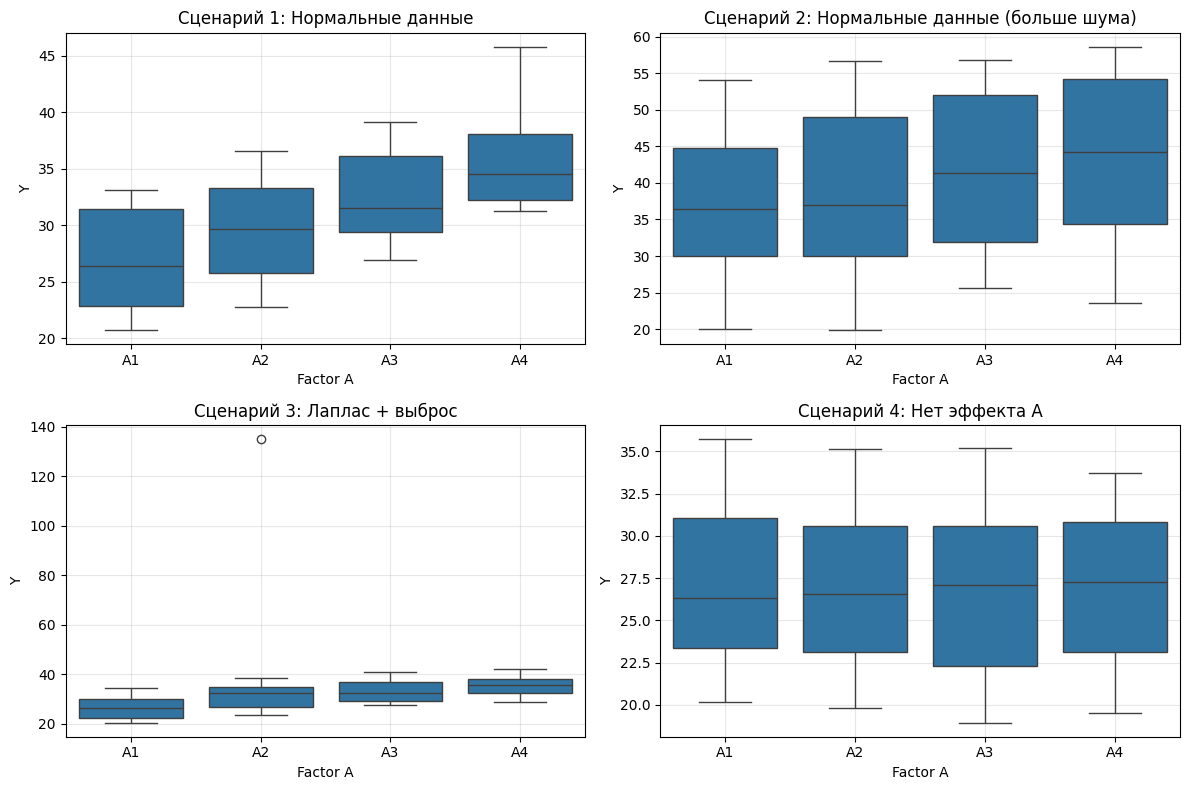

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import laplace
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

# Функции критериев
def friedman_test(data):
    stat, p = stats.friedmanchisquare(*data.T)
    return stat, p

def page_test(data):
    res = stats.page_trend_test(data, ranked=False, method='auto')
    return res.statistic, res.pvalue

def two_way_anova(data):
    df = pd.DataFrame(data)
    df_long = df.stack().reset_index()
    df_long.columns = ['B', 'A', 'Y']
    model = ols('Y ~ C(A) + C(B)', data=df_long).fit()
    anova_table = anova_lm(model, typ=2)
    f_stat = anova_table.loc['C(A)', 'F']
    p_val = anova_table.loc['C(A)', 'PR(>F)']
    return f_stat, p_val

def one_way_anova(data):
    groups = [data[:, j] for j in range(data.shape[1])]
    return stats.f_oneway(*groups)

# Генерация данных
def generate_data(mu, A_effects, B_effects, error_dist='norm', error_scale=1.5, outlier=None):
    n = len(B_effects)
    k = len(A_effects)
    Y = np.zeros((n, k))
    for i, beta in enumerate(B_effects):
        for j, alpha in enumerate(A_effects):
            if error_dist == 'norm':
                eps = np.random.normal(0, error_scale)
            elif error_dist == 'laplace':
                eps = laplace.rvs(0, error_scale)
            Y[i, j] = mu + alpha + beta + eps
    if outlier is not None:
        block_idx, level_idx, mult = outlier
        Y[block_idx, level_idx] *= mult
    return Y

mu = 20

# Сценарий 1
A1 = [0, 3, 6, 9]
B1 = [0, 2, 4, 6, 8, 10, 12, 14]
error_scale1 = 1.5
data1 = generate_data(mu, A1, B1, error_dist='norm', error_scale=error_scale1)

# Сценарий 2
A2 = [0, 2, 4, 6]
B2 = [0, 5, 10, 15, 20, 25, 30, 35]
error_scale2 = 2.0
data2 = generate_data(mu, A2, B2, error_dist='norm', error_scale=error_scale2)

# Сценарий 3
b_laplace = np.sqrt(1.125)
outlier3 = (2, 1, 5)
data3 = generate_data(mu, A1, B1, error_dist='laplace', error_scale=b_laplace, outlier=outlier3)

# Сценарий 4
A4 = [0, 0, 0, 0]
B4 = B1
error_scale4 = 1.5
data4 = generate_data(mu, A4, B4, error_dist='norm', error_scale=error_scale4)

# Оценка результатов
def evaluate_test(p_value, alpha=0.05, true_effect_exists=True):
    reject_h0 = p_value < alpha
    if true_effect_exists:
        return "Отвергаем H0 -> Истина" if reject_h0 else "Принимаем H0 -> Ошибка II рода"
    else:
        return "Отвергаем H0 -> Ошибка I рода" if reject_h0 else "Принимаем H0 -> Истина"

print("\nСценарий 1. Главный фактор влияет")
stat_page, p_page = page_test(data1)
print(f"  Пейдж: F-статистика = {stat_page:.4f}, p={p_page:.6f} -> {evaluate_test(p_page)}")
stat_fried, p_fried = friedman_test(data1)
print(f"  Фридман: F-статистика = {stat_fried:.4f}, p={p_fried:.6f} -> {evaluate_test(p_fried)}")
f_two, p_two = two_way_anova(data1)
print(f"  Двухфакторный ANOVA: F-статистика = {f_two:.4f}, p={p_two:.6f} -> {evaluate_test(p_two)}")

print("\nСценарий 2. Главный фактор влияет")
stat_page2, p_page2 = page_test(data2)
print(f"  Пейдж: F-статистика = {stat_page2:.4f}, p={p_page2:.6f} -> {evaluate_test(p_page2)}")
stat_fried2, p_fried2 = friedman_test(data2)
print(f"  Фридман: F-статистика = {stat_fried2:.4f}, p={p_fried2:.6f} -> {evaluate_test(p_fried2)}")
f_two2, p_two2 = two_way_anova(data2)
print(f"  Двухфакторный ANOVA: F-статистика = {f_two2:.4f}, p={p_two2:.6f} -> {evaluate_test(p_two2)}")
f_one2, p_one2 = one_way_anova(data2)
print(f"  Однофакторный ANOVA: F-статистика = {f_one2:.4f}, p={p_one2:.6f} -> {evaluate_test(p_one2)}")

print("\nСценарий 3. Главный фактор влияет (тяжёлые хвосты + выброс)")
stat_fried3, p_fried3 = friedman_test(data3)
print(f"  Фридман: F-статистика = {stat_fried3:.4f}, p={p_fried3:.6f} -> {evaluate_test(p_fried3)}")
f_two3, p_two3 = two_way_anova(data3)
print(f"  Двухфакторный ANOVA: F-статистика = {f_two3:.4f}, p={p_two3:.6f} -> {evaluate_test(p_two3)}")

print("\nСценарий 4. Главный фактор не влияет")
stat_fried4, p_fried4 = friedman_test(data4)
print(f"  Фридман: F-статистика = {stat_fried4:.4f}, p={p_fried4:.6f} -> {evaluate_test(p_fried4, true_effect_exists=False)}")
f_two4, p_two4 = two_way_anova(data4)
print(f"  Двухфакторный ANOVA: F-статистика = {f_two4:.4f}, p={p_two4:.6f} -> {evaluate_test(p_two4, true_effect_exists=False)}")

# Визуализация результатов
data_viz = {
    'Сценарий': ['Сценарий 1']*3 + ['Сценарий 2']*4 + ['Сценарий 3']*2 + ['Сценарий 4']*2,
    'Критерий': ['Пейдж', 'Фридман', 'Двухфакторный ANOVA',
                 'Пейдж', 'Фридман', 'Двухфакторный ANOVA', 'Однофакторный ANOVA',
                 'Фридман', 'Двухфакторный ANOVA',
                 'Фридман', 'Двухфакторный ANOVA'],
    'p_value': [p_page, p_fried, p_two,
                p_page2, p_fried2, p_two2, p_one2,
                p_fried3, p_two3,
                p_fried4, p_two4]
}
df_viz = pd.DataFrame(data_viz)
df_viz['p_value_display'] = df_viz['p_value'].replace(0, 1e-10)

custom_palette = {
    'Пейдж': '#2ca02c',
    'Фридман': '#9467bd',
    'Двухфакторный ANOVA': '#1f77b4',
    'Однофакторный ANOVA': '#ff7f0e'
}

plt.figure(figsize=(10, 5))
sns.barplot(data=df_viz, x='Сценарий', y='p_value_display', hue='Критерий', palette=custom_palette)
plt.yscale('log')
plt.ylabel('p-value (логарифмическая шкала)')
plt.axhline(y=0.05, color='red', linestyle='--', label='α = 0.05')
plt.title('Сравнение p‑значений критериев по сценариям')
plt.legend(title='Критерий')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Визуализация данных
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
datasets = [data1, data2, data3, data4]
titles = ['Сценарий 1: Нормальные данные', 'Сценарий 2: Нормальные данные (больше шума)',
          'Сценарий 3: Лаплас + выброс', 'Сценарий 4: Нет эффекта A']

for idx, (data, title) in enumerate(zip(datasets, titles)):
    ax = axes[idx // 2, idx % 2]
    df_plot = pd.DataFrame(data, columns=[f'A{i+1}' for i in range(data.shape[1])])
    df_plot_melted = df_plot.melt(var_name='Factor A', value_name='Y')
    sns.boxplot(data=df_plot_melted, x='Factor A', y='Y', ax=ax)
    ax.set_title(title)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()